# Лабораторная работа 2 — Heart Disease (вариант 17)

**Тема:** продвинутая инженерия признаков и отбор  
**Датасет:** Heart Disease (UCI / Cleveland)  
**Задача:** классификация `target`  
**Требования варианта:** Simple / KNN / Iterative · IsolationForest · Mutual Information + Lasso

### План ноутбука
1. Данные (MAR-пропуски + искусственные выбросы)  
2. Сравнение импутеров (CV ROC-AUC)  
3. Детекция выбросов + PCA  
4. Генерация признаков (`PolynomialFeatures`) и отбор (MI / Lasso)  
5. Финальный `imblearn.Pipeline` + оценка на отложенном test

In [1]:
from pathlib import Path
import sys
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
print("ROOT =", ROOT)

Matplotlib is building the font cache; this may take a moment.


ROOT = /Users/zesmolovaya/Desktop/Prpdv-m/heart-disease-ml


## 1. Загрузка данных

Пропусков в исходном UCI не было → для лабы 2 созданы:

- **MAR (~12%)** в `chol`, `trestbps`, `thalach`: вероятность пропуска растёт с `age`  
  *(обоснование: у более возрастных пациентов лабораторные поля чаще незаполнены — пропуск зависит от наблюдаемого возраста, не от скрытого значения)*
- **Искусственные выбросы:** часть значений ×5–10

In [2]:
from src.models.train_lab2 import (
    RAW_PATH, NUMERIC_BASE, CATEGORICAL, TARGET, RANDOM_STATE,
    load_xy, compare_imputers, plot_imputation_hist,
    detect_and_plot_outliers, compare_feature_selection,
    build_final_pipeline, train_final, METRICS_PATH, FIG_DIR,
)
from sklearn.model_selection import train_test_split
from src.features.transformers import IsolationForestOutlierRemover, AgeSquaredTransformer

X, y = load_xy()
df = pd.read_csv(RAW_PATH)
print("shape:", df.shape)
print("пропуски:")
display(df.isna().sum()[df.isna().sum() > 0].to_frame("n_missing"))
print("экстремумы (после выбросов):")
display(df[NUMERIC_BASE].agg(["min", "max", "mean"]).T.round(2))
print("баланс классов:")
display(y.value_counts(normalize=True).round(3).to_frame("share"))

shape: (303, 14)
пропуски:


,n_missing
trestbps,36
chol,36
thalach,36


экстремумы (после выбросов):


,min,max,mean
age,29.0,77.00,54.37
trestbps,94.0,1178.83,145.83
chol,126.0,2509.35,272.41
thalach,71.0,1640.55,170.16
oldpeak,0.0,6.20,1.04


баланс классов:


,share
target,
1,0.545
0,0.455


## 2. Train / test split

Тест **не участвует** в сравнении импутеров, отборе признаков и подборе гиперпараметров.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"train={len(X_train)}, test={len(X_test)}")

train=242, test=61


## 3. Сравнение методов импутации

| Метод | Числовые | Примечание |
|-------|----------|------------|
| Simple | медиана | baseline |
| KNN | `KNNImputer(k=5)` | перед импутацией — `NanSafeStandardScaler` |
| Iterative | `IterativeImputer` | то же масштабирование |

Модель внутри Pipeline: `LogisticRegression`, метрика — **ROC-AUC**, **5-fold CV**.

  simple: ROC-AUC=0.8792 ± 0.0386


  knn: ROC-AUC=0.8830 ± 0.0352


  iterative: ROC-AUC=0.8802 ± 0.0378


,imputer,cv_roc_auc_mean,cv_roc_auc_std
0,simple,0.8792,0.0386
1,knn,0.8830,0.0352
2,iterative,0.8802,0.0378


лучший импутер по CV: knn


сохранено: /Users/zesmolovaya/Desktop/Prpdv-m/heart-disease-ml/reports/figures/lab2_imputation_chol.png


![imputation](/Users/zesmolovaya/Desktop/Prpdv-m/heart-disease-ml/reports/figures/lab2_imputation_chol.png)

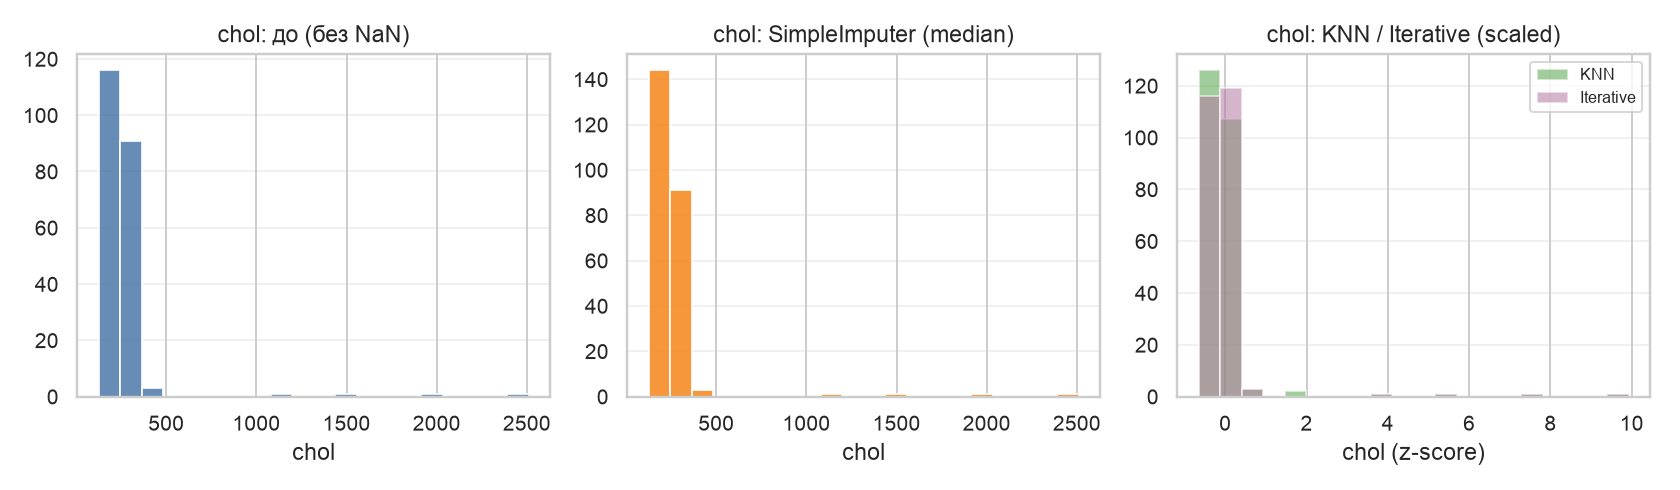

In [4]:
imp_df = compare_imputers(X_train, y_train)
display(imp_df.style.format({"cv_roc_auc_mean": "{:.4f}", "cv_roc_auc_std": "{:.4f}"}))
best_imp = imp_df.loc[imp_df["cv_roc_auc_mean"].idxmax(), "imputer"]
print("лучший импутер по CV:", best_imp)

fig_path = plot_imputation_hist(X_train)
print("сохранено:", fig_path)
display(Markdown(f"![imputation]({fig_path.as_posix()})"))
from IPython.display import Image
display(Image(filename=str(fig_path)))

## 4. Детекция выбросов — IsolationForest

Визуализация: PCA → 2D, выбросы отмечены цветом.  
Кастомный шаг `IsolationForestOutlierRemover` реализует `fit_resample` и встраивается в **`imblearn.pipeline.Pipeline`**, поэтому удаляет аномалии **только из train**.

найдено выбросов на train: 13


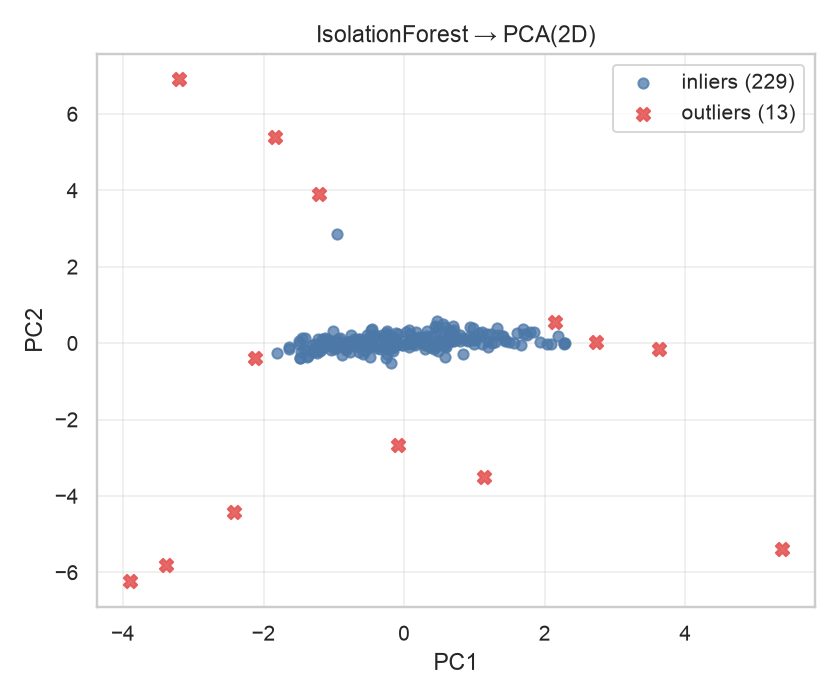

до: 242 → после: 229 (удалено 13)


In [5]:
out_info = detect_and_plot_outliers(X_train)
print(f"найдено выбросов на train: {out_info['n_outliers']}")
display(Image(filename=out_info["figure"]))

# демонстрация кастомного remover
remover = IsolationForestOutlierRemover(
    contamination=0.05, random_state=RANDOM_STATE, numeric_cols=NUMERIC_BASE
)
X_clean, y_clean = remover.fit_resample(X_train, y_train)
print(f"до: {len(X_train)} → после: {len(X_clean)} (удалено {remover.n_removed_})")

## 5. Генерация и отбор признаков

Датасет одиночный → **не Featuretools**, а `PolynomialFeatures(degree=2)` на числовых (+ `age_squared`).

Отбор (вариант 17):
1. **Mutual Information** — `SelectKBest(mutual_info_classif)`
2. **Lasso / L1** — `SelectFromModel(LogisticRegression(penalty='l1'))`

Сравнение CV ROC-AUC до и после отбора.

In [6]:
sel_df = compare_feature_selection(X_train, y_train)
display(sel_df)

  all_poly_features: ROC-AUC=0.8707 ± 0.0338
  mutual_info_SelectKBest: ROC-AUC=0.8649 ± 0.0553
  lasso_SelectFromModel: ROC-AUC=0.8752 ± 0.0406


,method,n_features,cv_roc_auc_mean,cv_roc_auc_std
0,all_poly_features,52,0.870746,0.033766
1,mutual_info_SelectKBest,30,0.864854,0.055323
2,lasso_SelectFromModel,adaptive,0.875188,0.040577


## 6. Финальный пайплайн

```
AgeSquaredTransformer
  → IsolationForestOutlierRemover   # только train (imblearn)
  → ColumnTransformer
       num: NanSafeScaler → IterativeImputer → PolynomialFeatures
       cat: mode → OneHotEncoder
  → SelectFromModel (L1 / Lasso-like)
  → LogisticRegression
```

Подбор: `GridSearchCV` по `model__C` и `outlier_remover__contamination`.  
Оценка — **только на отложенном test**.

загружены готовые метрики из /Users/zesmolovaya/Desktop/Prpdv-m/heart-disease-ml/reports/lab2_metrics.json
best_params: {'model__C': 2.0, 'outlier_remover__contamination': 0.03}
CV ROC-AUC:     0.8726
Test accuracy:  0.8525
Test ROC-AUC:   0.8582


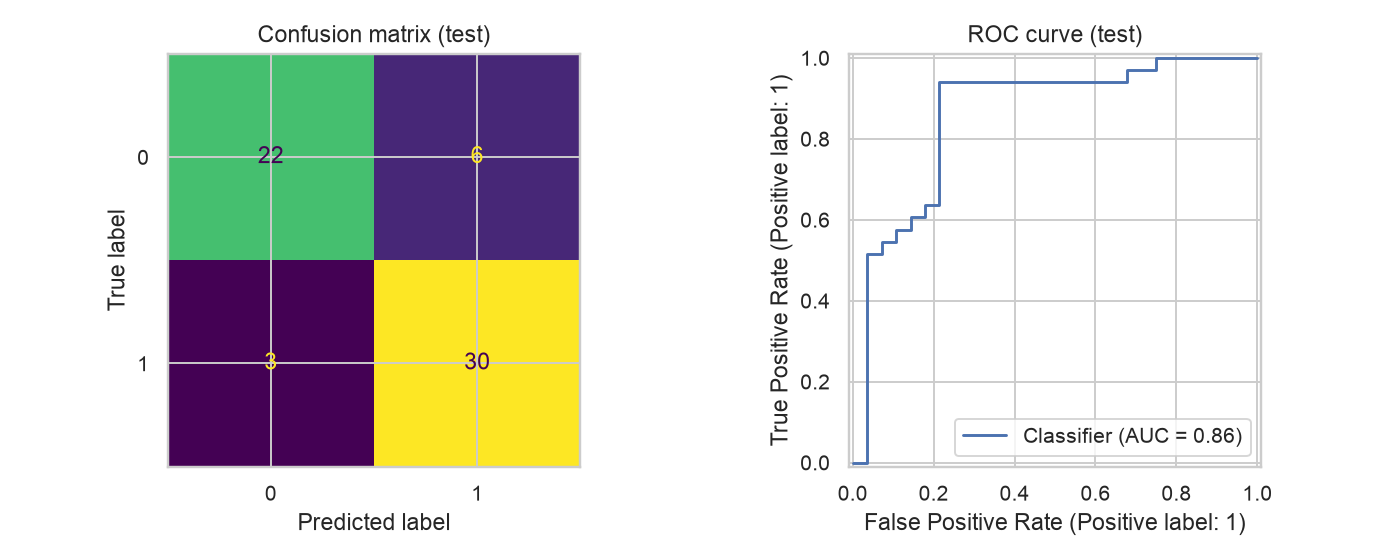

In [7]:
# если метрики уже посчитаны скриптом — можно загрузить; иначе обучить здесь
metrics_file = ROOT / "reports" / "lab2_metrics.json"
model_file = ROOT / "models" / "heart_disease_lab2_pipeline.joblib"

if metrics_file.exists() and model_file.exists():
    import joblib
    payload = json.loads(metrics_file.read_text(encoding="utf-8"))
    best = joblib.load(model_file)
    final = payload["final"]
    print("загружены готовые метрики из", metrics_file)
else:
    final = train_final(X_train, y_train, X_test, y_test)
    best = None
    payload = {"final": final}

print("best_params:", final["best_params"])
print(f"CV ROC-AUC:     {final['cv_best_roc_auc']:.4f}")
print(f"Test accuracy:  {final['test_accuracy']:.4f}")
print(f"Test ROC-AUC:   {final['test_roc_auc']:.4f}")

fig_final = ROOT / "reports" / "figures" / "lab2_final_metrics.png"
if fig_final.exists():
    display(Image(filename=str(fig_final)))

## 7. Выводы

| Этап | Главный результат |
|------|-------------------|
| Импутация | KNN чуть лучше Simple/Iterative по CV ROC-AUC |
| Выбросы | IsolationForest + PCA; remover режет только train |
| Отбор | Lasso/L1 слегка лучше полного poly-набора и MI |
| Финал | Полный пайплайн, test ROC-AUC ≈ 0.86 |

Наибольший практический вклад дают **аккуратная импутация (KNN)** и **регуляризованный отбор (L1)**; полиномиальные признаки без отбора качество почти не улучшают (мало строк, риск переобучения).

In [8]:
# сводная таблица для отчёта
summary = {
    "best_imputer_cv": float(imp_df["cv_roc_auc_mean"].max()),
    "best_selection_cv": float(sel_df["cv_roc_auc_mean"].max()),
    "final_test_roc_auc": float(final["test_roc_auc"]),
    "final_test_accuracy": float(final["test_accuracy"]),
}
display(pd.Series(summary).to_frame("value").round(4))
print("Модель:", ROOT / "models" / "heart_disease_lab2_pipeline.joblib")
print("Метрики:", metrics_file)

,value
best_imputer_cv,0.8830
best_selection_cv,0.8752
final_test_roc_auc,0.8582
final_test_accuracy,0.8525


Модель: /Users/zesmolovaya/Desktop/Prpdv-m/heart-disease-ml/models/heart_disease_lab2_pipeline.joblib
Метрики: /Users/zesmolovaya/Desktop/Prpdv-m/heart-disease-ml/reports/lab2_metrics.json
